In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(737.5), np.float64(368.5), np.float64(-0.5))

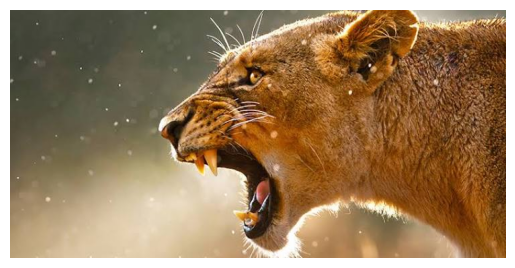

In [10]:
noise_image = cv2.cvtColor(
    cv2.imread(r"C:\academics\codes\DSIP\Images (1).jpg"),
    cv2.COLOR_BGR2RGB
)
plt.imshow(noise_image)
plt.axis("off")

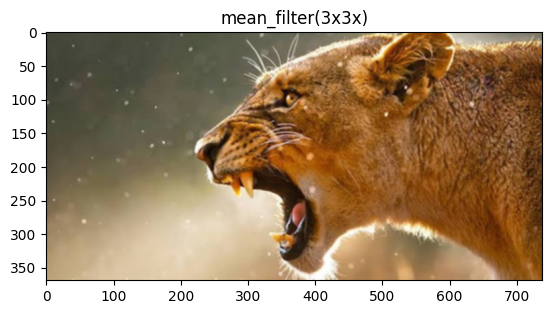

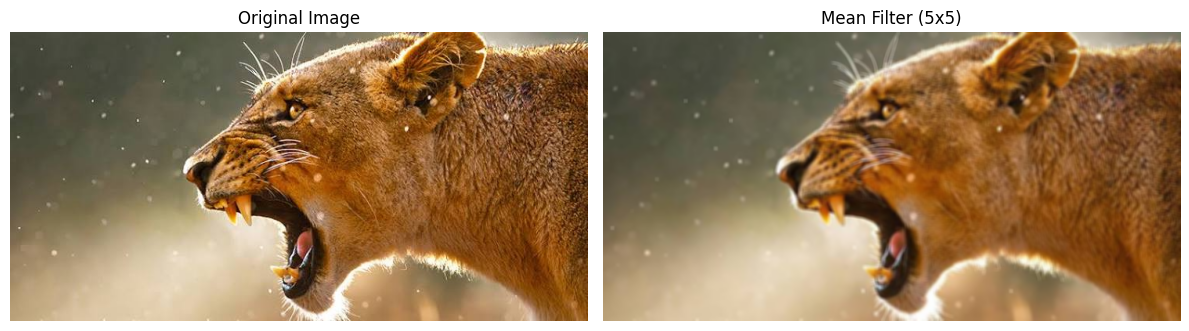

In [11]:
plt.title("mean_filter(3x3x)")
mean_3x3 = cv2.blur(noise_image, ( 3,3))
plt.imshow(mean_3x3)
mean_5x5 = cv2.blur(noise_image, (5 ,5))
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(noise_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean_5x5)
           
plt.title("Mean Filter (5x5)")
plt.axis("off")

plt.tight_layout()
plt.show()

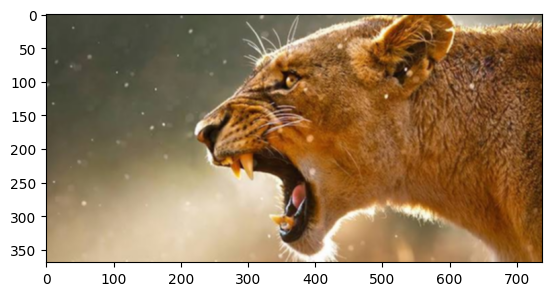

In [12]:
weighted_kernal = np.array([[1,1,1],[1,2,1],[1,1,1]],dtype=np.float32)
weighted_kernal = weighted_kernal/10
weighted_kernal = cv2.filter2D(noise_image,-1,weighted_kernal)
plt.imshow(weighted_kernal)

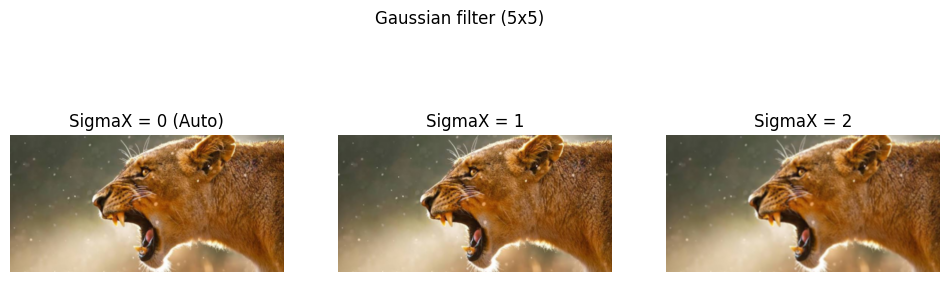

In [8]:
g0 = cv2.GaussianBlur(noise_image, (5, 5), sigmaX=0)
g1 = cv2.GaussianBlur(noise_image, (5, 5), sigmaX=1)
g2 = cv2.GaussianBlur(noise_image, (5, 5), sigmaX=2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(g0, cv2.COLOR_BGR2RGB))
plt.title('SigmaX = 0 (Auto)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(g1, cv2.COLOR_BGR2RGB))
plt.title('SigmaX = 1')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(g2, cv2.COLOR_BGR2RGB))
plt.title('SigmaX = 2')
plt.axis('off')

plt.suptitle('Gaussian filter (5x5)')
plt.show()

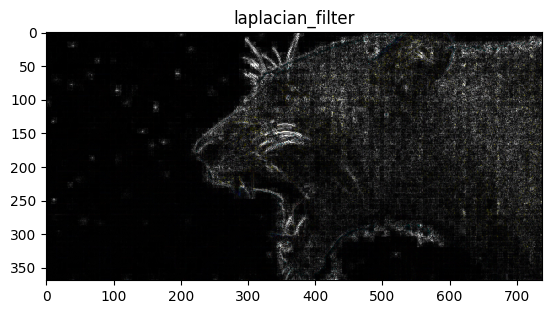

In [13]:
laplacian = cv2.Laplacian(noise_image,cv2.CV_64F)

laplacian_abs = cv2.convertScaleAbs(laplacian)

plt.imshow(laplacian_abs,cmap='gray')
plt.title("laplacian_filter")
plt.show()

In [14]:
roberts_x = np.asarray([
    [1,0],
    [0,-1]
],dtype=np.float32)
roberts_y = np.asarray([
    [0,1],
    [-1,0]
],dtype=np.float32)
print(roberts_x)
print(roberts_y)




[[ 1.  0.]
 [ 0. -1.]]
[[ 0.  1.]
 [-1.  0.]]


In [15]:

gx = cv2.filter2D(noise_image.astype(np.float32), cv2.CV_32F, roberts_x)
print(gx)


[[[ 0.  0.  0.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]
  ...
  [ 3.  1.  0.]
  [ 3.  1.  1.]
  [ 2.  0. -2.]]

 [[ 0.  0.  0.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]
  ...
  [-1.  1.  2.]
  [-1.  1.  4.]
  [-2.  0.  2.]]

 [[ 1.  1.  1.]
  [ 1.  1.  1.]
  [ 1.  1.  1.]
  ...
  [-2.  2.  5.]
  [-3.  1.  6.]
  [-4.  0.  3.]]

 ...

 [[ 0.  0.  0.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]
  ...
  [-7. -8. -3.]
  [ 0.  1.  6.]
  [ 5.  4.  9.]]

 [[ 0.  0.  0.]
  [ 0.  0.  0.]
  [-1. -1. -1.]
  ...
  [-7. -5.  0.]
  [ 6.  7. 14.]
  [ 8.  7. 12.]]

 [[-1. -1. -1.]
  [-1. -1. -1.]
  [-2. -2. -2.]
  ...
  [ 9.  9. 15.]
  [14. 14. 23.]
  [ 2.  1.  5.]]]


In [16]:
gy = cv2.filter2D(noise_image.astype(np.float32), cv2.CV_32F, roberts_y)
print(gy)



[[[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [  1.  -1.  -2.]
  [  1.  -1.  -4.]
  [  2.   0.  -2.]]

 [[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [ -3.  -1.   0.]
  [ -3.  -1.  -1.]
  [ -2.   0.   2.]]

 [[  1.   1.   1.]
  [  1.   1.   1.]
  [  1.   1.   1.]
  ...
  [ -4.   1.   1.]
  [ -4.   0.   1.]
  [ -4.   0.   3.]]

 ...

 [[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [ -5.  -7. -11.]
  [ -8.  -9. -14.]
  [ -8.  -8. -10.]]

 [[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [ -8.  -7. -10.]
  [-12. -13. -17.]
  [ -7.  -6.  -9.]]

 [[ -1.  -1.  -1.]
  [ -1.  -1.  -1.]
  [  0.   0.   0.]
  ...
  [ -8.  -6.  -7.]
  [ -5.  -5.  -9.]
  [ -6.  -6.  -6.]]]


In [17]:
roberts= cv2.magnitude(gx,gy)
print(roberts)

[[[ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  ...
  [ 3.1622777  1.4142135  2.       ]
  [ 3.1622777  1.4142135  4.1231055]
  [ 2.828427   0.         2.828427 ]]

 [[ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  ...
  [ 3.1622777  1.4142135  2.       ]
  [ 3.1622777  1.4142135  4.1231055]
  [ 2.828427   0.         2.828427 ]]

 [[ 1.4142135  1.4142135  1.4142135]
  [ 1.4142135  1.4142135  1.4142135]
  [ 1.4142135  1.4142135  1.4142135]
  ...
  [ 4.472136   2.236068   5.0990195]
  [ 5.         1.         6.0827622]
  [ 5.656854   0.         4.2426405]]

 ...

 [[ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  ...
  [ 8.602325  10.630146  11.401753 ]
  [ 8.         9.055386  15.231547 ]
  [ 9.433981   8.944272  13.453624 ]]

 [[ 0.         0.         0.       ]
  [ 0.         0.         0.       ]


[[[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 2  1  1]
  [ 2  1  3]
  [ 2  0  2]]

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 2  1  1]
  [ 2  1  3]
  [ 2  0  2]]

 [[ 1  1  1]
  [ 1  1  1]
  [ 1  1  1]
  ...
  [ 3  1  4]
  [ 4  0  5]
  [ 4  0  3]]

 ...

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 7  8  9]
  [ 6  7 12]
  [ 7  7 11]]

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 8  7  8]
  [11 12 18]
  [ 8  7 12]]

 [[ 1  1  1]
  [ 1  1  1]
  [ 1  1  1]
  ...
  [ 9  8 13]
  [12 12 20]
  [ 5  5  6]]]


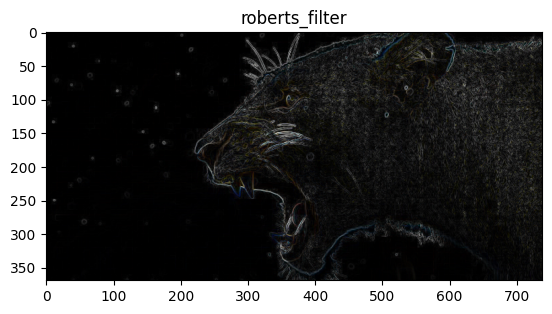

In [18]:
roberts = cv2.normalize(roberts,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)

print(roberts)
plt.imshow(roberts,cmap='gray')
plt.title("roberts_filter")
plt.show()




In [19]:
prewit_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]],dtype= np.float32)
prewit_y = np.array([[-1,-1,-1], [0, 0, 0], [1, 1, 1]],dtype= np.float32)


In [20]:
px = cv2.filter2D(noise_image.astype(np.float32), cv2.CV_32F, prewit_x)
print(px)

[[[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [ -6.  -6. -11.]
  [ -3.  -3.  -8.]
  [  0.   0.   0.]]

 [[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [ -5.  -4. -12.]
  [ -2.  -2.  -7.]
  [  0.   0.   0.]]

 [[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [ -5.  -3. -14.]
  [ -3.  -3. -10.]
  [  0.   0.   0.]]

 ...

 [[  0.   0.   0.]
  [  1.   1.   1.]
  [  2.   2.   2.]
  ...
  [-20. -23. -52.]
  [-41. -42. -68.]
  [  0.   0.   0.]]

 [[  0.   0.   0.]
  [  2.   2.   2.]
  [  3.   3.   3.]
  ...
  [-41. -42. -71.]
  [-40. -39. -66.]
  [  0.   0.   0.]]

 [[  0.   0.   0.]
  [  3.   3.   3.]
  [  3.   3.   3.]
  ...
  [-50. -48. -78.]
  [-47. -46. -72.]
  [  0.   0.   0.]]]


In [21]:
py = cv2.filter2D(noise_image.astype(np.float32), cv2.CV_32F, prewit_y)
print(py)

[[[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]]

 [[ -3.  -3.  -3.]
  [ -3.  -3.  -3.]
  [ -3.  -3.  -3.]
  ...
  [ 16.  -3. -13.]
  [ 17.  -1. -15.]
  [ 18.   0. -15.]]

 [[ -3.  -3.  -3.]
  [ -3.  -3.  -3.]
  [ -3.  -3.  -3.]
  ...
  [ 16.  -6. -14.]
  [ 16.  -5. -17.]
  [ 15.  -6. -17.]]

 ...

 [[  0.   0.   0.]
  [  1.   1.   1.]
  [  2.   2.   2.]
  ...
  [ 29.  29.  24.]
  [ 14.  15.   9.]
  [  4.   5.  -2.]]

 [[  3.   3.   3.]
  [  4.   4.   4.]
  [  4.   4.   4.]
  ...
  [ 12.   8.  -4.]
  [  2.   2.  -7.]
  [  1.   3.  -8.]]

 [[  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]
  ...
  [  0.   0.   0.]
  [  0.   0.   0.]
  [  0.   0.   0.]]]


In [22]:
prewit = cv2.magnitude(px,py)
print(prewit)

[[[ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  [ 0.         0.         0.       ]
  ...
  [ 6.         6.        11.       ]
  [ 3.         3.         8.       ]
  [ 0.         0.         0.       ]]

 [[ 3.         3.         3.       ]
  [ 3.         3.         3.       ]
  [ 3.         3.         3.       ]
  ...
  [16.763056   5.        17.691807 ]
  [17.117243   2.236068  16.552946 ]
  [18.         0.        15.       ]]

 [[ 3.         3.         3.       ]
  [ 3.         3.         3.       ]
  [ 3.         3.         3.       ]
  ...
  [16.763056   6.7082043 19.79899  ]
  [16.27882    5.8309517 19.723083 ]
  [15.000001   6.        17.       ]]

 ...

 [[ 0.         0.         0.       ]
  [ 1.4142135  1.4142135  1.4142135]
  [ 2.828427   2.828427   2.828427 ]
  ...
  [35.22783   37.01351   57.271286 ]
  [43.324356  44.59821   68.593    ]
  [ 4.         5.         2.       ]]

 [[ 3.         3.         3.       ]
  [ 4.472136   4.472136   4.472136 ]


[[[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 2  2  3]
  [ 1  1  2]
  [ 0  0  0]]

 [[ 1  1  1]
  [ 1  1  1]
  [ 1  1  1]
  ...
  [ 5  1  6]
  [ 5  0  5]
  [ 6  0  5]]

 [[ 1  1  1]
  [ 1  1  1]
  [ 1  1  1]
  ...
  [ 5  2  6]
  [ 5  2  6]
  [ 5  2  5]]

 ...

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [12 12 20]
  [15 15 23]
  [ 1  1  0]]

 [[ 1  1  1]
  [ 1  1  1]
  [ 1  1  1]
  ...
  [14 14 24]
  [14 13 23]
  [ 0  1  2]]

 [[ 0  0  0]
  [ 1  1  1]
  [ 1  1  1]
  ...
  [17 16 27]
  [16 16 25]
  [ 0  0  0]]]


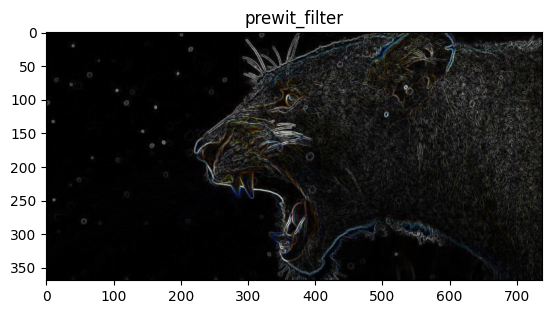

In [25]:
prewit = cv2.normalize(prewit,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
print(prewit)
plt.imshow(prewit,cmap='gray')      
plt.title("prewit_filter")
plt.show()

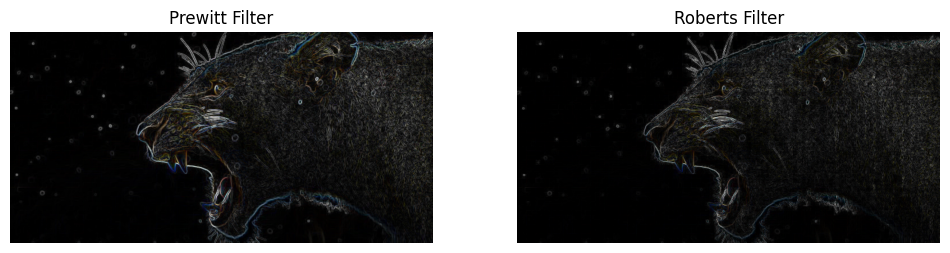

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(prewit, cmap='gray')
plt.title("Prewitt Filter")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roberts, cmap='gray')
plt.title("Roberts Filter")
plt.axis("off")

plt.show()

(np.float64(-0.5), np.float64(737.5), np.float64(368.5), np.float64(-0.5))

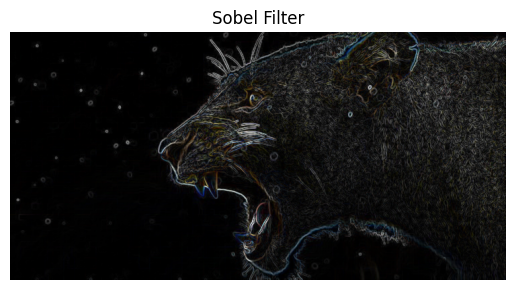

In [23]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
sx = cv2.filter2D(noise_image.astype(np.float32), cv2.CV_32F, sobel_x)
sy = cv2.filter2D(noise_image.astype(np.float32), cv2.CV_32F, sobel_y)  
sobel = cv2.magnitude(sx, sy)   
sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(sobel, cmap='gray')  
plt.title("Sobel Filter")
plt.axis("off") 